In [1]:
import pandas as pd 
import os
import platform
import sqlite3

In [2]:
if "pop-os" in platform.node():
    ROOT = r"/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/"
else:
    ROOT = r'/gpfs/home4/athamma/repo/ss-llm/nanoGPT/'
    
TOKENIZER_ROOT = os.path.join(ROOT, "data")
OUT_ROOT = os.path.join(ROOT, "output_dump")
RESULTS_ROOT = os.path.join(ROOT, "results")

SQL_DB = os.path.join(RESULTS_ROOT, "results.db")


def create_connection_cursor(db_file):
    """
    Create a database connection to the SQLite database specified by the db_file

    Args:
        db_file (str): database file

    Returns:
        Connection object or None
    """
    conn = sqlite3.connect(db_file)
    c = conn.cursor()
    return conn, c

conn, c = create_connection_cursor(SQL_DB)

In [3]:
##Data Reading and Preprocessing Block
#Set current working directory to the root of the project
os.chdir("/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/final_paper_stuff")
data_dump_path = r'rundata.xlsx'
run_details_sheet = "Run Details"
loss_sheet = "Loss"
blimp_sheet = "BLIMP"
rt_sheet = "Reading Time"

TASKS = {
    "blimp": ["anaphor_agreement.json", "argument_structure.json", "binding.json",
              "control_raising.json", "determiner_noun_agreement.json", "ellipsis.json",
              "filler_gap.json", "irregular_forms.json", "island_effects.json",
              "npi_licensing.json", "quantifiers.json", "subject_verb_agreement.json"],
    "supplement": ["hypernym.json", "qa_congruence_easy.json", "qa_congruence_tricky.json",
               "subject_aux_inversion.json", "turn_taking.json"]
}
blimp_categories = [[x.split(".json")[0], "blimp"] for x in TASKS["blimp"]]
blimp_categories.extend([[x.split(".json")[0], "supplement"] for x in TASKS["supplement"]])

blimp_name_map = {
    "anaphor_agreement": "Anaphor Agreement", "argument_structure": "Argument Structure", "binding": "Binding", "control_raising": "Control Raising",
    "determiner_noun_agreement": "Determiner Noun Agreement", "ellipsis": "Ellipsis", "filler_gap": "Filler Gap", "irregular_forms": "Irregular Forms",
    "island_effects": "Island Effects", "npi_licensing": "NPI Licensing", "quantifiers": "Quantifiers", "subject_verb_agreement": "Subject Verb Agreement",
    "hypernym": "Hypernym", "qa_congruence_easy": "QA Congruence Easy", "qa_congruence_tricky": "QA Congruence Tricky",
    "subject_aux_inversion": "Subject Aux Inversion", "turn_taking": "Turn Taking"
}


run_data = pd.read_excel(data_dump_path, sheet_name=run_details_sheet) #Data contains a few duplicate runs for same Settings. They have been ignored in the below code wherever necessary
loss_data = pd.read_excel(data_dump_path, sheet_name=loss_sheet)
blimp_data = pd.read_excel(data_dump_path, sheet_name=blimp_sheet)

#Reading time data for Natural Stories SPRT, data from Thesis Time. Can be ignored for now
rt_data = pd.read_excel(data_dump_path, sheet_name=rt_sheet)
rt_subj_data = pd.read_excel(data_dump_path, sheet_name="Reading Time Subjectwise")



#Wil and Wil2 are 2 different fits described in Wilcox et al (Or more specifically, Fit 1 is used in their codebase but Fit 2 is described in the paper)
# Fit 1 - LogRT ~ CharacterLength_c + prev_len_c + prev2_len_c + prev3_len_c + LogFrequencies_c + prev_freq_c + prev2_freq_c + prev3_freq_c + SurprisalScore_c + prev_surp_c + prev2_surp_c + prev3_surp_c
# Fit 2 - LogRT ~ SurprisalScore_c + prev_surp_c + prev2_surp_c + prev3_surp_c + CharacterLength_c*LogFrequencies_c + prev_len_c*prev_freq_c + prev2_len_c*prev2_freq_c + prev3_len_c*prev3_freq_c

reading_time_fit_csv_osh = r'surprisal_analysis_results_v2.csv'
reading_time_fit_csv_osh = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/reading_time_analysis/surprisal_analysis_results_v2.csv'
reading_time_fit_csv_wil = r'surprisal_analysis_results_v3.csv'
reading_time_fit_csv_wil2 = r'surprisal_analysis_results_v4.csv'



reading_time_fit_df_osh = pd.read_csv(reading_time_fit_csv_osh)
reading_time_fit_df_wil = pd.read_csv(reading_time_fit_csv_wil)
reading_time_fit_df_wil2 = pd.read_csv(reading_time_fit_csv_wil2)

reading_time_fit_csv_osh_dundee = r"surprisal_analysis_results_oshdundee.csv"
reading_time_fit_csv_osh_dundee = r"/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/dundee/surprisal_analysis_results_oshdundee.csv"

reading_time_fit_csv_wil_dundee = r"surprisal_analysis_results_wilcoxdundee_v1.csv"
reading_time_fit_csv_wil2_dundee = r"surprisal_analysis_results_wilcoxdundee.csv"

reading_time_fit_df_osh_dundee = pd.read_csv(reading_time_fit_csv_osh_dundee)
reading_time_fit_df_wil_dundee = pd.read_csv(reading_time_fit_csv_wil_dundee)
reading_time_fit_df_wil2_dundee = pd.read_csv(reading_time_fit_csv_wil2_dundee)

run_data_unfiltered = run_data

#Filter only for seed 1337 (defaul seed used before Multiseed experiments)
run_data = run_data[run_data["seed"] == 1337].reset_index(drop=True)

run_data

,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,seed,masking,...,blimp_exists,wandb_exists,reading_time_exists,model_surprisal_data_exists,runtime,rough_sbu_estimate,epochs,wandb_runid,num_iterations,gradient_accumulation_steps
0,5444724,out-babylm_full_bpe-4x4-nomask-5444724,4,4,128,256,32.0,0.0010,1337,False,...,True,True,True,True,0:15:38,155,100.824615,5o1o8tm8,44000.0,8.0
1,5445338,out-babylm_wocdes_full_bpe-4x4-nomask-5445338,4,4,128,256,32.0,0.0005,1337,False,...,True,True,True,True,0:15:32,155,100.824615,hffttavi,44000.0,8.0
2,5492054,out-babylm_full_bpe-8x8-nomask-5492054,8,8,512,512,32.0,0.0005,1337,False,...,True,True,True,True,1:03:36,559,403.298462,ddnlzu6p,44000.0,8.0
3,5492134,out-babylm_full_bpe-6x6-nomask-5492134,6,6,256,384,32.0,0.0005,1337,False,...,True,True,True,True,0:23:14,227,201.649231,ub67nse1,44000.0,8.0
4,5496426,out-babylm_full_bpe_8k-8x8-nomask-5496426,8,8,512,512,32.0,0.0005,1337,False,...,True,True,True,True,0:56:01,524,403.298462,7paxvcyz,44000.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,8465077,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,6,6,256,384,32.0,0.0005,1337,True,...,True,True,False,True,0:29:17,281,20.164923,fa90igv0,44000.0,8.0
82,8569444,out-babylm_full_bpe_100M_8k-6x6-nomask-8569444,6,6,256,384,32.0,0.0005,1337,False,...,True,True,False,True,2:34:03,1350,161.319385,bwnyrmnf,352000.0,8.0
83,8569446,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,6,6,256,384,32.0,0.0005,1337,True,...,True,True,False,True,3:25:28,1781,161.319385,7r98oxlt,352000.0,8.0
84,8612955,out-babylm_full_bpe_8k-6x6-nomask-8612955,6,6,256,384,32.0,0.0005,1337,False,...,False,True,False,False,2:32:56,1332,1613.193846,98x9nve9,352000.0,8.0


In [4]:
#Create dataframe of all runs for Masking condition exponential , EM 10, 10M and 100M 

#40 Models

#TODO 

# From RTModelPredict Table, Get Word level prediction and calculate mean square error for each model
# Join with Story to get word's POS 
# Find it for all 40 models in the setup - 2 masked, 2 unmasked, 10M anmd 100M

# Get the list of models

MODEL_LIST_QUERY = """SELECT DISTINCT ModelSurprisalScores.ModelID, Model.Dataset, Model.Seed, Model.MaskType FROM ModelSurprisalScores
JOIN Model on Model.ModelID = ModelSurprisalScores.ModelID
WHERE Model.NumLayers = 6 
AND Model.BatchSize = 32
AND ((Model.EchoicMemory=10 AND Model.MaskType="exponential_new" AND Model.MaskDecayRate=2) OR (Model.MaskType="Non" AND Model.CurriculumLearning=False)) 
AND Model.Dataset in ("babylm_full_bpe_8k", "babylm_full_bpe_100M_8k")  
AND Model.ModelID not in (5496427, 8456913)
ORDER BY Seed, BatchSize, Dataset, MaskType"""

model_list_df = pd.read_sql_query(MODEL_LIST_QUERY, conn)

model_list_df["Dataset"] = model_list_df["Dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})
model_list_df["MaskType"] = model_list_df["MaskType"].replace({"Non": "Unmasked", "exponential_new": "Masked"})

model_list_df["Dataset"] = pd.Categorical(model_list_df["Dataset"], ordered=True)

#Make MaskType as categorical with order Unmasked, Masked
model_list_df["MaskType"] = pd.Categorical(model_list_df["MaskType"], ordered=True, categories=["Unmasked", "Masked"])

model_list_df = model_list_df.rename(columns={"ModelID": "Model ID", "Dataset": "Dataset", "Seed": "Seed", "MaskType": "Mask Type"})


model_list_df

,Model ID,Dataset,Seed,Mask Type
0,8465733,100M,9,Unmasked
1,8465085,100M,9,Masked
2,6892214,10M,9,Unmasked
3,6839425,10M,9,Masked
4,8465604,100M,42,Unmasked
5,8465082,100M,42,Masked
6,6892212,10M,42,Unmasked
7,6839403,10M,42,Masked
8,8465611,100M,466,Unmasked
9,8465091,100M,466,Masked


In [5]:
#Pivot model on same dataset, Seed to get pairs of unmasked and masked 

pivot_model_list_df = model_list_df.pivot(index=["Dataset", "Seed"], columns="Mask Type", values="Model ID").reset_index()

pivot_model_list_df = pivot_model_list_df.rename(columns={"Unmasked": "Unmasked Model ID", "Masked": "Masked Model ID"})

pivot_model_list_df


Mask Type,Dataset,Seed,Unmasked Model ID,Masked Model ID
0,100M,9,8465733,8465085
1,100M,42,8465604,8465082
2,100M,466,8465611,8465091
3,100M,616,8465607,8465086
4,100M,869,8465610,8465090
5,100M,1337,8096895,8465077
6,100M,2347,8465605,8465084
7,100M,6747,8465609,8465089
8,100M,11111,8465612,8465093
9,100M,46674,8465608,8465087


In [6]:
#Join Loss, Blimp, delta_log_likelihood, reading time data with the model list

pivot_model_list_df_with_data = pivot_model_list_df.copy()

#Join with loss data
pivot_model_list_df_with_data = pivot_model_list_df_with_data.merge(loss_data[["run_id", "val_loss"]], how="left", left_on="Unmasked Model ID", right_on="run_id").rename(columns={"val_loss": "Unmasked Loss"}).drop(columns=["run_id"])
pivot_model_list_df_with_data = pivot_model_list_df_with_data.merge(loss_data[["run_id", "val_loss"]], how="left", left_on="Masked Model ID", right_on="run_id").rename(columns={"val_loss": "Masked Loss"}).drop(columns=["run_id"])

#Calculate delta loss
pivot_model_list_df_with_data["Delta Loss"] = pivot_model_list_df_with_data["Masked Loss"] - pivot_model_list_df_with_data["Unmasked Loss"]

#Join with blimp data
pivot_model_list_df_with_data = pivot_model_list_df_with_data.merge(blimp_data[["run_id", "blimp_avg"]], how="left", left_on="Unmasked Model ID", right_on="run_id").rename(columns={"blimp_avg": "Unmasked BLIMP"}).drop(columns=["run_id"])
pivot_model_list_df_with_data = pivot_model_list_df_with_data.merge(blimp_data[["run_id", "blimp_avg"]], how="left", left_on="Masked Model ID", right_on="run_id").rename(columns={"blimp_avg": "Masked BLIMP"}).drop(columns=["run_id"])
#Calculate delta blimp
pivot_model_list_df_with_data["Delta BLIMP"] = pivot_model_list_df_with_data["Masked BLIMP"] - pivot_model_list_df_with_data["Unmasked BLIMP"]

#Join with reading time data
#2 types of RT Data - sprt and dundee

#SPRT
pivot_model_list_df_with_data = pivot_model_list_df_with_data.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood"]], how="left", left_on="Unmasked Model ID", right_on="ModelID").rename(columns={"Delta Log-Likelihood": "Unmasked SPRT DLL"}).drop(columns=["ModelID"])
pivot_model_list_df_with_data = pivot_model_list_df_with_data.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood"]], how="left", left_on="Masked Model ID", right_on="ModelID").rename(columns={"Delta Log-Likelihood": "Masked SPRT DLL"}).drop(columns=["ModelID"])
#Calculate delta reading time
pivot_model_list_df_with_data["Delta SPRT DLL"] = pivot_model_list_df_with_data["Masked SPRT DLL"] - pivot_model_list_df_with_data["Unmasked SPRT DLL"]

#Dundee
pivot_model_list_df_with_data = pivot_model_list_df_with_data.merge(reading_time_fit_df_osh_dundee[["ModelID", "Delta Log-Likelihood"]], how="left", left_on="Unmasked Model ID", right_on="ModelID").rename(columns={"Delta Log-Likelihood": "Unmasked Dundee DLL"}).drop(columns=["ModelID"])
pivot_model_list_df_with_data = pivot_model_list_df_with_data.merge(reading_time_fit_df_osh_dundee[["ModelID", "Delta Log-Likelihood"]], how="left", left_on="Masked Model ID", right_on="ModelID").rename(columns={"Delta Log-Likelihood": "Masked Dundee DLL"}).drop(columns=["ModelID"])

#Calculate delta reading time
pivot_model_list_df_with_data["Delta Dundee DLL"] = pivot_model_list_df_with_data["Masked Dundee DLL"] - pivot_model_list_df_with_data["Unmasked Dundee DLL"]


pivot_model_list_df_with_data

,Dataset,Seed,Unmasked Model ID,Masked Model ID,Unmasked Loss,Masked Loss,Delta Loss,Unmasked BLIMP,Masked BLIMP,Delta BLIMP,Unmasked SPRT DLL,Masked SPRT DLL,Delta SPRT DLL,Unmasked Dundee DLL,Masked Dundee DLL,Delta Dundee DLL
0,100M,9,8465733,8465085,3.428438,3.407000,-0.021439,70.313922,73.686026,3.372104,1610.186220,1539.560098,-70.626122,1179.907176,1190.281987,10.374811
1,100M,42,8465604,8465082,3.431483,3.405324,-0.026159,74.208030,75.093966,0.885936,1561.673614,1529.104944,-32.568669,1206.562597,1173.556693,-33.005904
2,100M,466,8465611,8465091,3.436505,3.413875,-0.022630,71.719081,73.685521,1.966440,1669.994199,1589.009702,-80.984497,1196.978760,1166.665799,-30.312960
3,100M,616,8465607,8465086,3.435688,3.412756,-0.022932,73.742465,73.639511,-0.102953,1627.548660,1515.071062,-112.477599,1215.044604,1170.644030,-44.400573
4,100M,869,8465610,8465090,3.431461,3.413790,-0.017670,71.616473,75.301732,3.685259,1610.745179,1595.656280,-15.088900,1208.843726,1174.809280,-34.034446
5,100M,1337,8096895,8465077,3.436880,3.413841,-0.023039,71.448756,75.600544,4.151788,1593.381797,1604.989983,11.608186,1195.831247,1162.093804,-33.737443
6,100M,2347,8465605,8465084,3.446280,3.418787,-0.027493,71.051583,75.316957,4.265374,1622.851437,1579.994062,-42.857375,1173.211556,1179.641566,6.430010
7,100M,6747,8465609,8465089,3.439447,3.416155,-0.023293,73.238700,73.460490,0.221790,1612.407471,1547.854572,-64.552899,1195.681392,1180.716095,-14.965297
8,100M,11111,8465612,8465093,3.434575,3.414013,-0.020562,71.916138,75.294936,3.378798,1615.068179,1671.041745,55.973567,1173.763395,1173.434624,-0.328771
9,100M,46674,8465608,8465087,3.424394,3.406032,-0.018362,71.783722,73.779456,1.995735,1665.004971,1520.978682,-144.026288,1184.012349,1158.279103,-25.733246


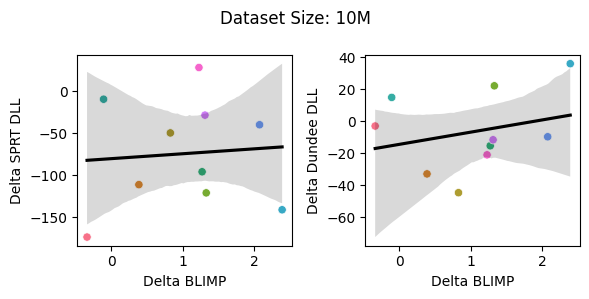

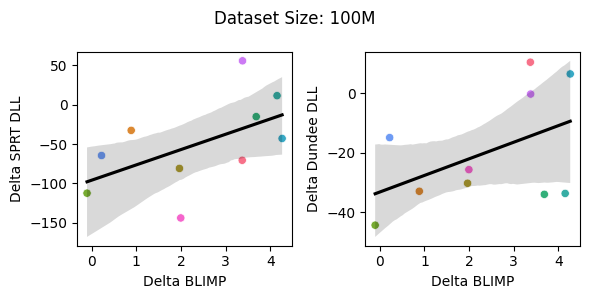

In [7]:
#Plot 2x2 scatter plot plotting, for each dataset, the delta blimp vs delta sprt, delta blimp vs delta dundee
# 
import matplotlib.pyplot as plt
import seaborn as sns

#Assign Each seed a distinct color
colors = sns.color_palette("husl", len(pivot_model_list_df_with_data["Seed"].unique()))
seed_color_map = {seed: color for seed, color in zip(pivot_model_list_df_with_data["Seed"].unique(), colors)}


for dataset_size in ["10M", "100M"]:
    dataset_df = pivot_model_list_df_with_data[pivot_model_list_df_with_data["Dataset"] == dataset_size]
    
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    

    #Delta BLIMP vs Delta SPRT
    sns.scatterplot(data=dataset_df, x="Delta BLIMP", y="Delta SPRT DLL", ax=axes[0], hue="Seed", palette=seed_color_map)
    axes[0].set_xlabel("Delta BLIMP")
    axes[0].set_ylabel("Delta SPRT DLL")

    #Delete the legend
    axes[0].legend_.remove()

    #Fit a linear regression line to the data
    sns.regplot(data=dataset_df, x="Delta BLIMP", y="Delta SPRT DLL", ax=axes[0], scatter=False, color="black")
    

    #Delta BLIMP vs Delta Dundee
    sns.scatterplot(data=dataset_df, x="Delta BLIMP", y="Delta Dundee DLL", ax=axes[1], hue="Seed", palette=seed_color_map)
    #Fit a linear regression line to the data
    sns.regplot(data=dataset_df, x="Delta BLIMP", y="Delta Dundee DLL", ax=axes[1], scatter=False, color="black")
    axes[1].legend_.remove()
    axes[1].set_xlabel("Delta BLIMP")
    axes[1].set_ylabel("Delta Dundee DLL")
    
    #Set title
    fig.suptitle(f"Dataset Size: {dataset_size}")
    plt.tight_layout()
    plt.show()  

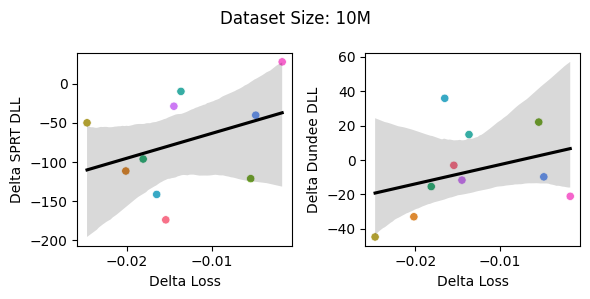

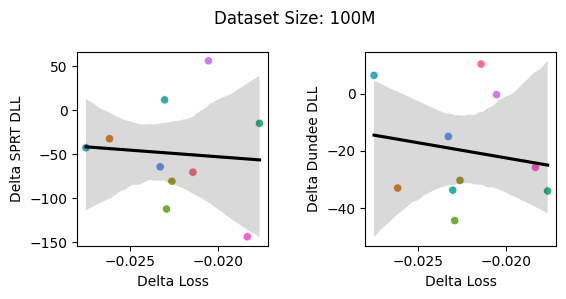

In [8]:
#Plot 2x2 scatter plot plotting, for each dataset, the delta blimp vs delta sprt, delta blimp vs delta dundee
# 
import matplotlib.pyplot as plt
import seaborn as sns

#Assign Each seed a distinct color
colors = sns.color_palette("husl", len(pivot_model_list_df_with_data["Seed"].unique()))
seed_color_map = {seed: color for seed, color in zip(pivot_model_list_df_with_data["Seed"].unique(), colors)}


for dataset_size in ["10M", "100M"]:
    dataset_df = pivot_model_list_df_with_data[pivot_model_list_df_with_data["Dataset"] == dataset_size]
    
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    

    #Delta BLIMP vs Delta SPRT
    sns.scatterplot(data=dataset_df, x="Delta Loss", y="Delta SPRT DLL", ax=axes[0], hue="Seed", palette=seed_color_map)
    axes[0].set_xlabel("Delta Loss")
    axes[0].set_ylabel("Delta SPRT DLL")

    #Delete the legend
    axes[0].legend_.remove()

    #Fit a linear regression line to the data
    sns.regplot(data=dataset_df, x="Delta Loss", y="Delta SPRT DLL", ax=axes[0], scatter=False, color="black")
    

    #Delta BLIMP vs Delta Dundee
    sns.scatterplot(data=dataset_df, x="Delta Loss", y="Delta Dundee DLL", ax=axes[1], hue="Seed", palette=seed_color_map)
    #Fit a linear regression line to the data
    sns.regplot(data=dataset_df, x="Delta Loss", y="Delta Dundee DLL", ax=axes[1], scatter=False, color="black")
    axes[1].legend_.remove()
    axes[1].set_xlabel("Delta Loss")
    axes[1].set_ylabel("Delta Dundee DLL")
    
    #Set title
    fig.suptitle(f"Dataset Size: {dataset_size}")
    plt.tight_layout()
    plt.show()  

In [ ]:
#Plot 2x2 scatter plot plotting, for each dataset, the delta blimp vs delta sprt, delta blimp vs delta dundee
# 
import matplotlib.pyplot as plt
import seaborn as sns

#Assign Each seed a distinct color
colors = sns.color_palette("husl", len(pivot_model_list_df_with_data["Seed"].unique()))
seed_color_map = {seed: color for seed, color in zip(pivot_model_list_df_with_data["Seed"].unique(), colors)}


for dataset_size in ["10M", "100M"]:
    dataset_df = pivot_model_list_df_with_data[pivot_model_list_df_with_data["Dataset"] == dataset_size]
    
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    

    #Delta BLIMP vs Delta SPRT
    sns.scatterplot(data=dataset_df, x="Delta Loss", y="Delta BLIMP", ax=axes[0], hue="Seed", palette=seed_color_map)
    axes[0].set_xlabel("Delta Loss")
    axes[0].set_ylabel("Delta SPRT DLL")

    #Delete the legend
    axes[0].legend_.remove()

    #Fit a linear regression line to the data
    sns.regplot(data=dataset_df, x="Delta Loss", y="Delta #Plot 2x2 scatter plot plotting, for each dataset, the delta blimp vs delta sprt, delta blimp vs delta dundee
# 
import matplotlib.pyplot as plt
import seaborn as sns

#Assign Each seed a distinct color
colors = sns.color_palette("husl", len(pivot_model_list_df_with_data["Seed"].unique()))
seed_color_map = {seed: color for seed, color in zip(pivot_model_list_df_with_data["Seed"].unique(), colors)}


for dataset_size in ["10M", "100M"]:
    dataset_df = pivot_model_list_df_with_data[pivot_model_list_df_with_data["Dataset"] == dataset_size]
    
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    

    #Delta BLIMP vs Delta SPRT
    sns.scatterplot(data=dataset_df, x="Delta Loss", y="Delta SPRT DLL", ax=axes[0], hue="Seed", palette=seed_color_map)
    axes[0].set_xlabel("Delta Loss")
    axes[0].set_ylabel("Delta SPRT DLL")

    #Delete the legend
    axes[0].legend_.remove()

    #Fit a linear regression line to the data
    sns.regplot(data=dataset_df, x="Delta Loss", y="Delta SPRT DLL", ax=axes[0], scatter=False, color="black")
    

    #Delta BLIMP vs Delta Dundee
    sns.scatterplot(data=dataset_df, x="Delta Loss", y="Delta Dundee DLL", ax=axes[1], hue="Seed", palette=seed_color_map)
    #Fit a linear regression line to the data
    sns.regplot(data=dataset_df, x="Delta Loss", y="Delta Dundee DLL", ax=axes[1], scatter=False, color="black")
    axes[1].legend_.remove()
    axes[1].set_xlabel("Delta Loss")
    axes[1].set_ylabel("Delta Dundee DLL")
    
    #Set title
    fig.suptitle(f"Dataset Size: {dataset_size}")
    plt.tight_layout()
    plt.show()  ", ax=axes[0], scatter=False, color="black")
    

    #Delta BLIMP vs Delta Dundee
    sns.scatterplot(data=dataset_df, x="Delta Loss", y="Delta Dundee DLL", ax=axes[1], hue="Seed", palette=seed_color_map)
    #Fit a linear regression line to the data
    sns.regplot(data=dataset_df, x="Delta Loss", y="Delta Dundee DLL", ax=axes[1], scatter=False, color="black")
    axes[1].legend_.remove()
    axes[1].set_xlabel("Delta Loss")
    axes[1].set_ylabel("Delta Dundee DLL")
    
    #Set title
    fig.suptitle(f"Dataset Size: {dataset_size}")
    plt.tight_layout()
    plt.show()  